In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import displacement as dpm
from libs import fit_model as fm 
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

In [2]:
scale = 0.11
interval = 2

path = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251225/MC03MT/beads_tracks.csv"

track = cv.cal(pd.read_csv(path), scale=scale ,frame_interval=interval)

fast=track[track['v']>0.36]

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(


In [3]:
track

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle,v,theta,alpha,t,dtheta,omega
0,1854.906634,976.594113,158682.400000,21.479715,0.194873,79.600000,1625853.0,NaN,0,2,NaN,NaN,NaN,0,NaN,NaN
1,1650.447258,1712.655691,165507.200000,21.511024,0.171718,68.800000,1716289.0,NaN,0,5,NaN,NaN,NaN,0,NaN,NaN
2,966.998152,1503.439630,132686.000000,17.132632,0.047987,88.800000,1512828.0,NaN,0,12,NaN,NaN,NaN,0,NaN,NaN
3,613.811720,353.271198,143293.200000,18.676042,0.198691,102.000000,1410785.0,NaN,0,15,NaN,NaN,NaN,0,NaN,NaN
4,488.588607,1345.364071,119841.600000,17.660942,0.094961,89.600000,1495438.0,NaN,0,16,NaN,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7393,1461.586884,1719.254977,94305.941159,16.990357,0.099736,71.901961,1652217.0,NaN,1000,162,0.028150,1.370678,0.174515,2000,-0.749266,-0.374633
7394,314.701409,264.337233,136612.235268,21.047545,0.310562,86.803922,1536954.0,NaN,1000,490,0.052175,2.072276,1.960377,2000,-2.917793,-1.458896
7395,884.890912,1591.758226,105363.568608,16.664209,0.056063,81.960784,1567787.0,NaN,1000,200,0.023133,0.217287,-1.235229,2000,-0.236561,-0.118281
7396,262.393465,1795.554363,172074.058791,27.415370,0.152288,58.490196,1822101.0,NaN,1000,59,0.114605,0.204850,0.189884,2000,-3.111660,-1.555830


(array([1011.,  576.,  453.,  432.,  402.,  523.,  661.,  731., 1083.,
        1474.]),
 array([2.46590604e-04, 3.14375801e-01, 6.28505012e-01, 9.42634223e-01,
        1.25676343e+00, 1.57089264e+00, 1.88502186e+00, 2.19915107e+00,
        2.51328028e+00, 2.82740949e+00, 3.14153870e+00]),
 <BarContainer object of 10 artists>)

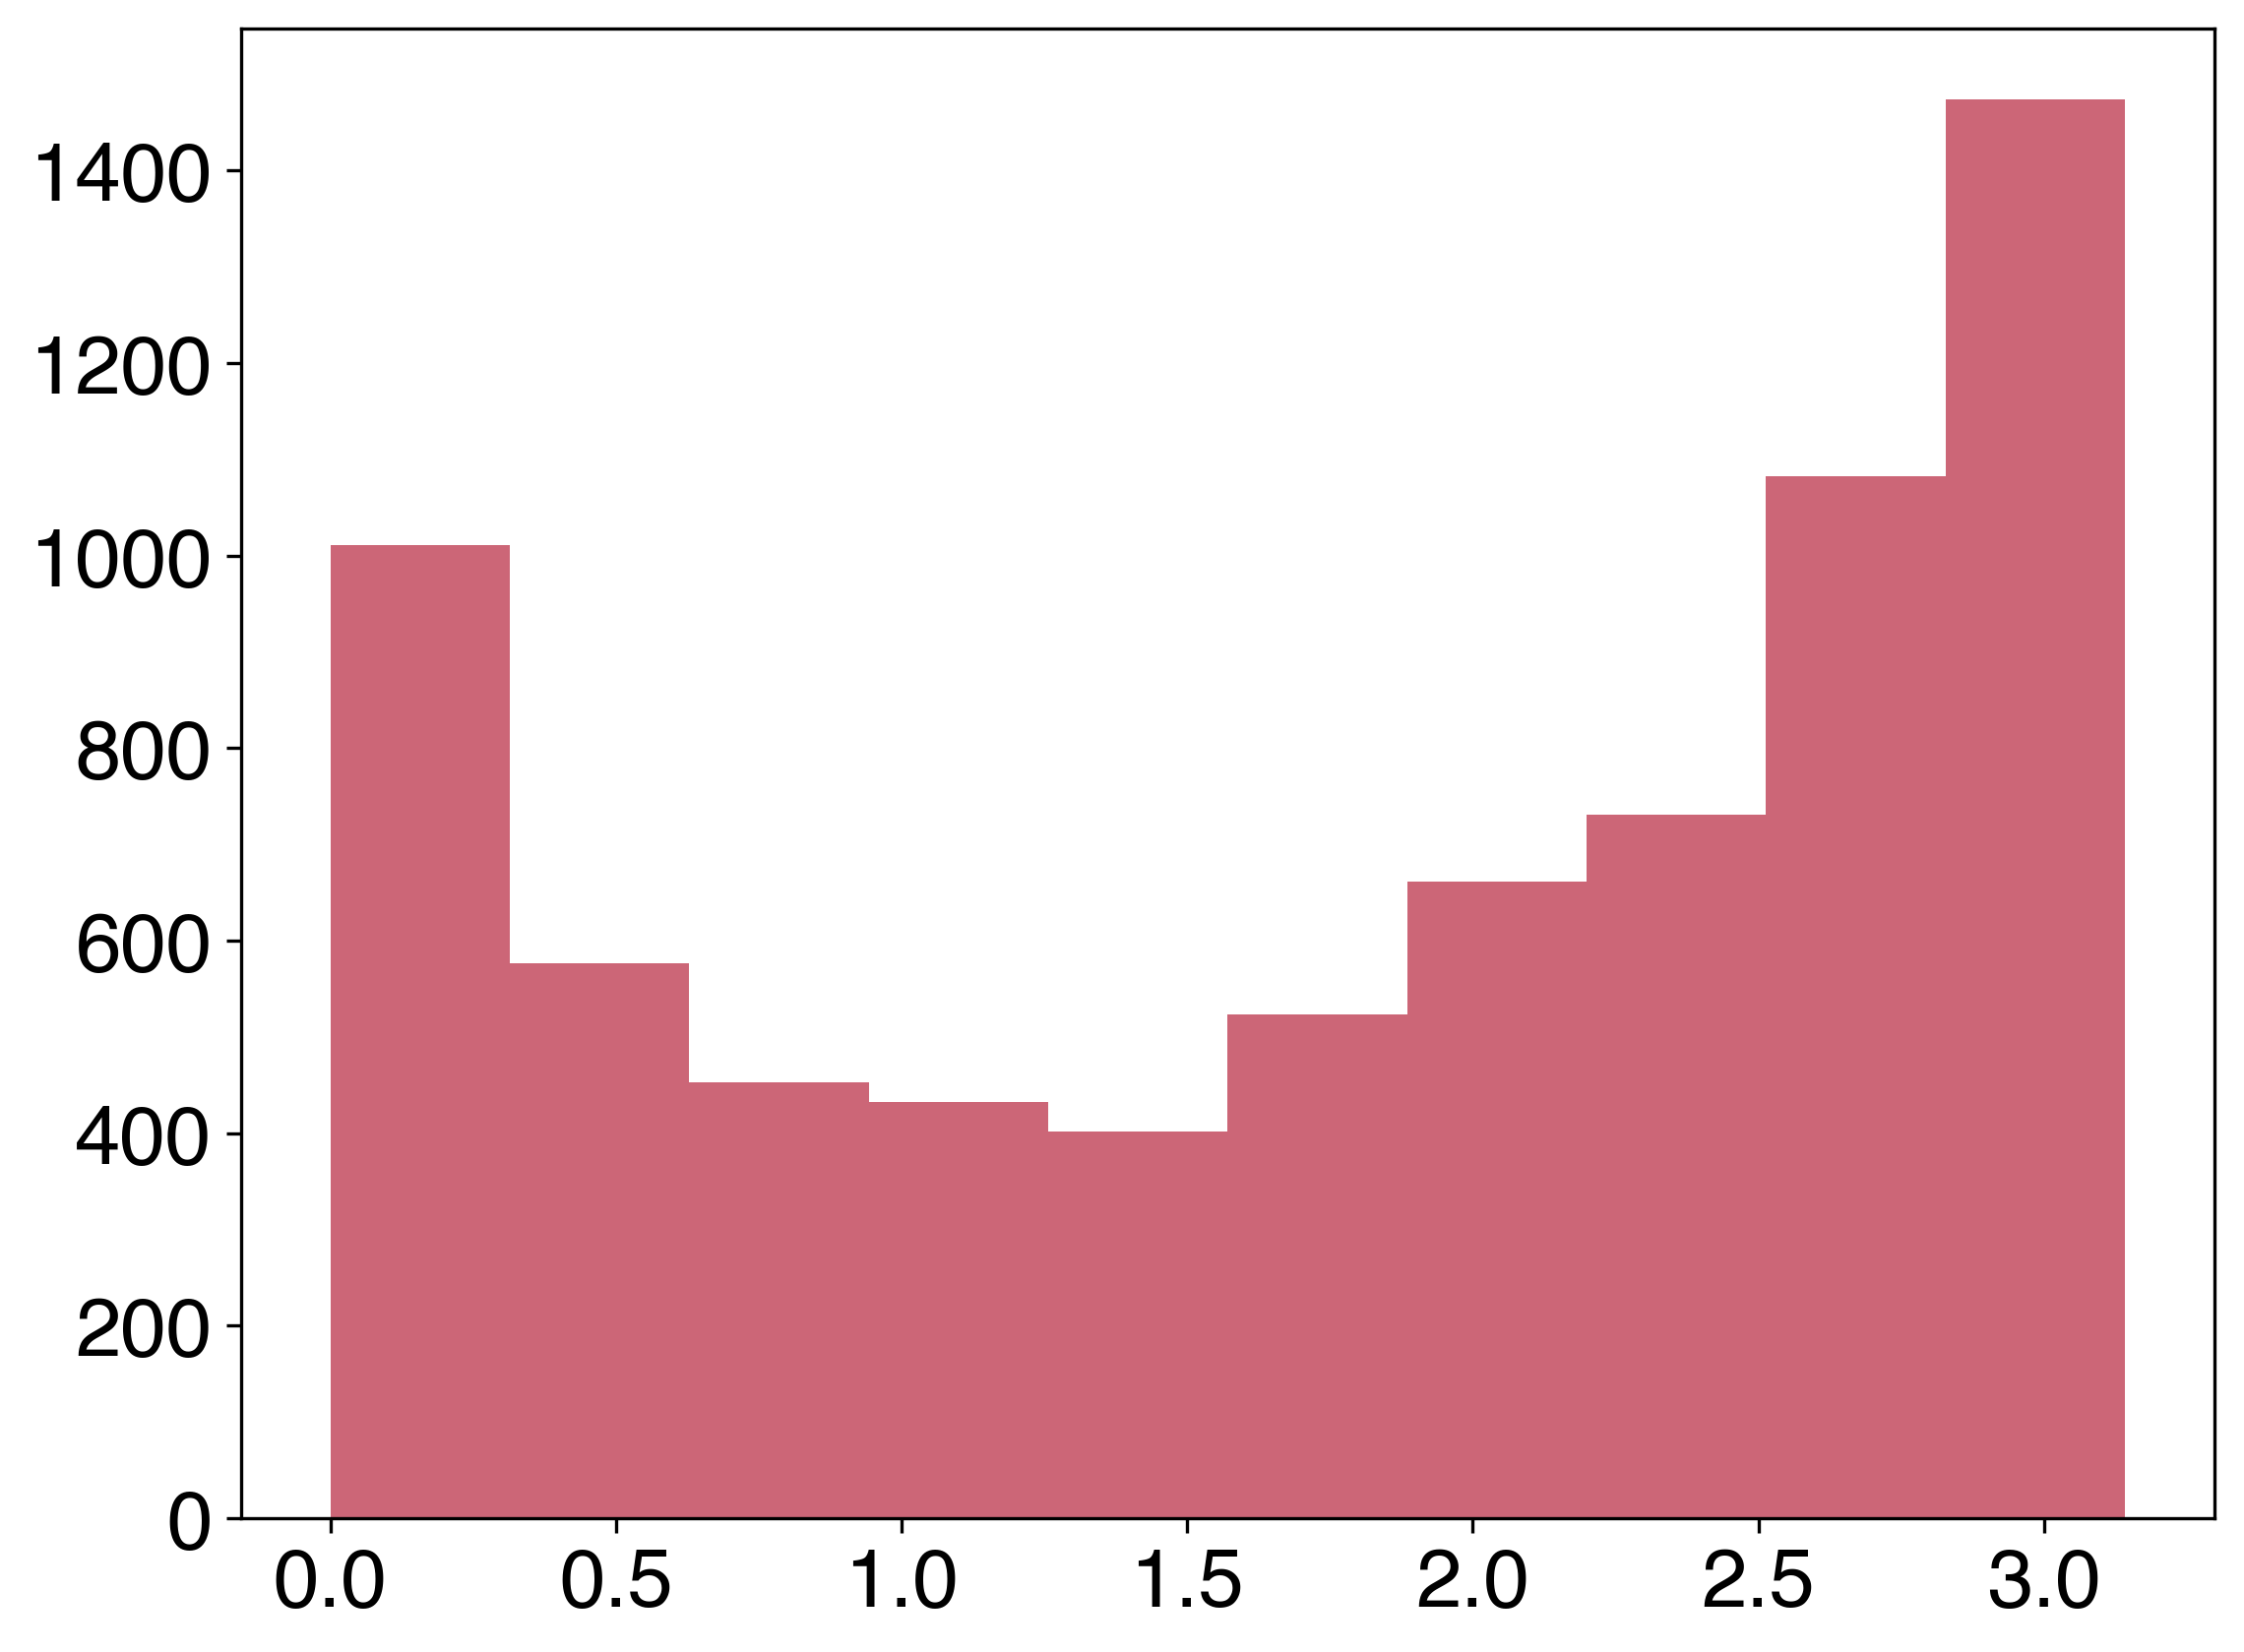

In [4]:
plt.hist(np.abs(track['dtheta'].to_numpy()))

[None]

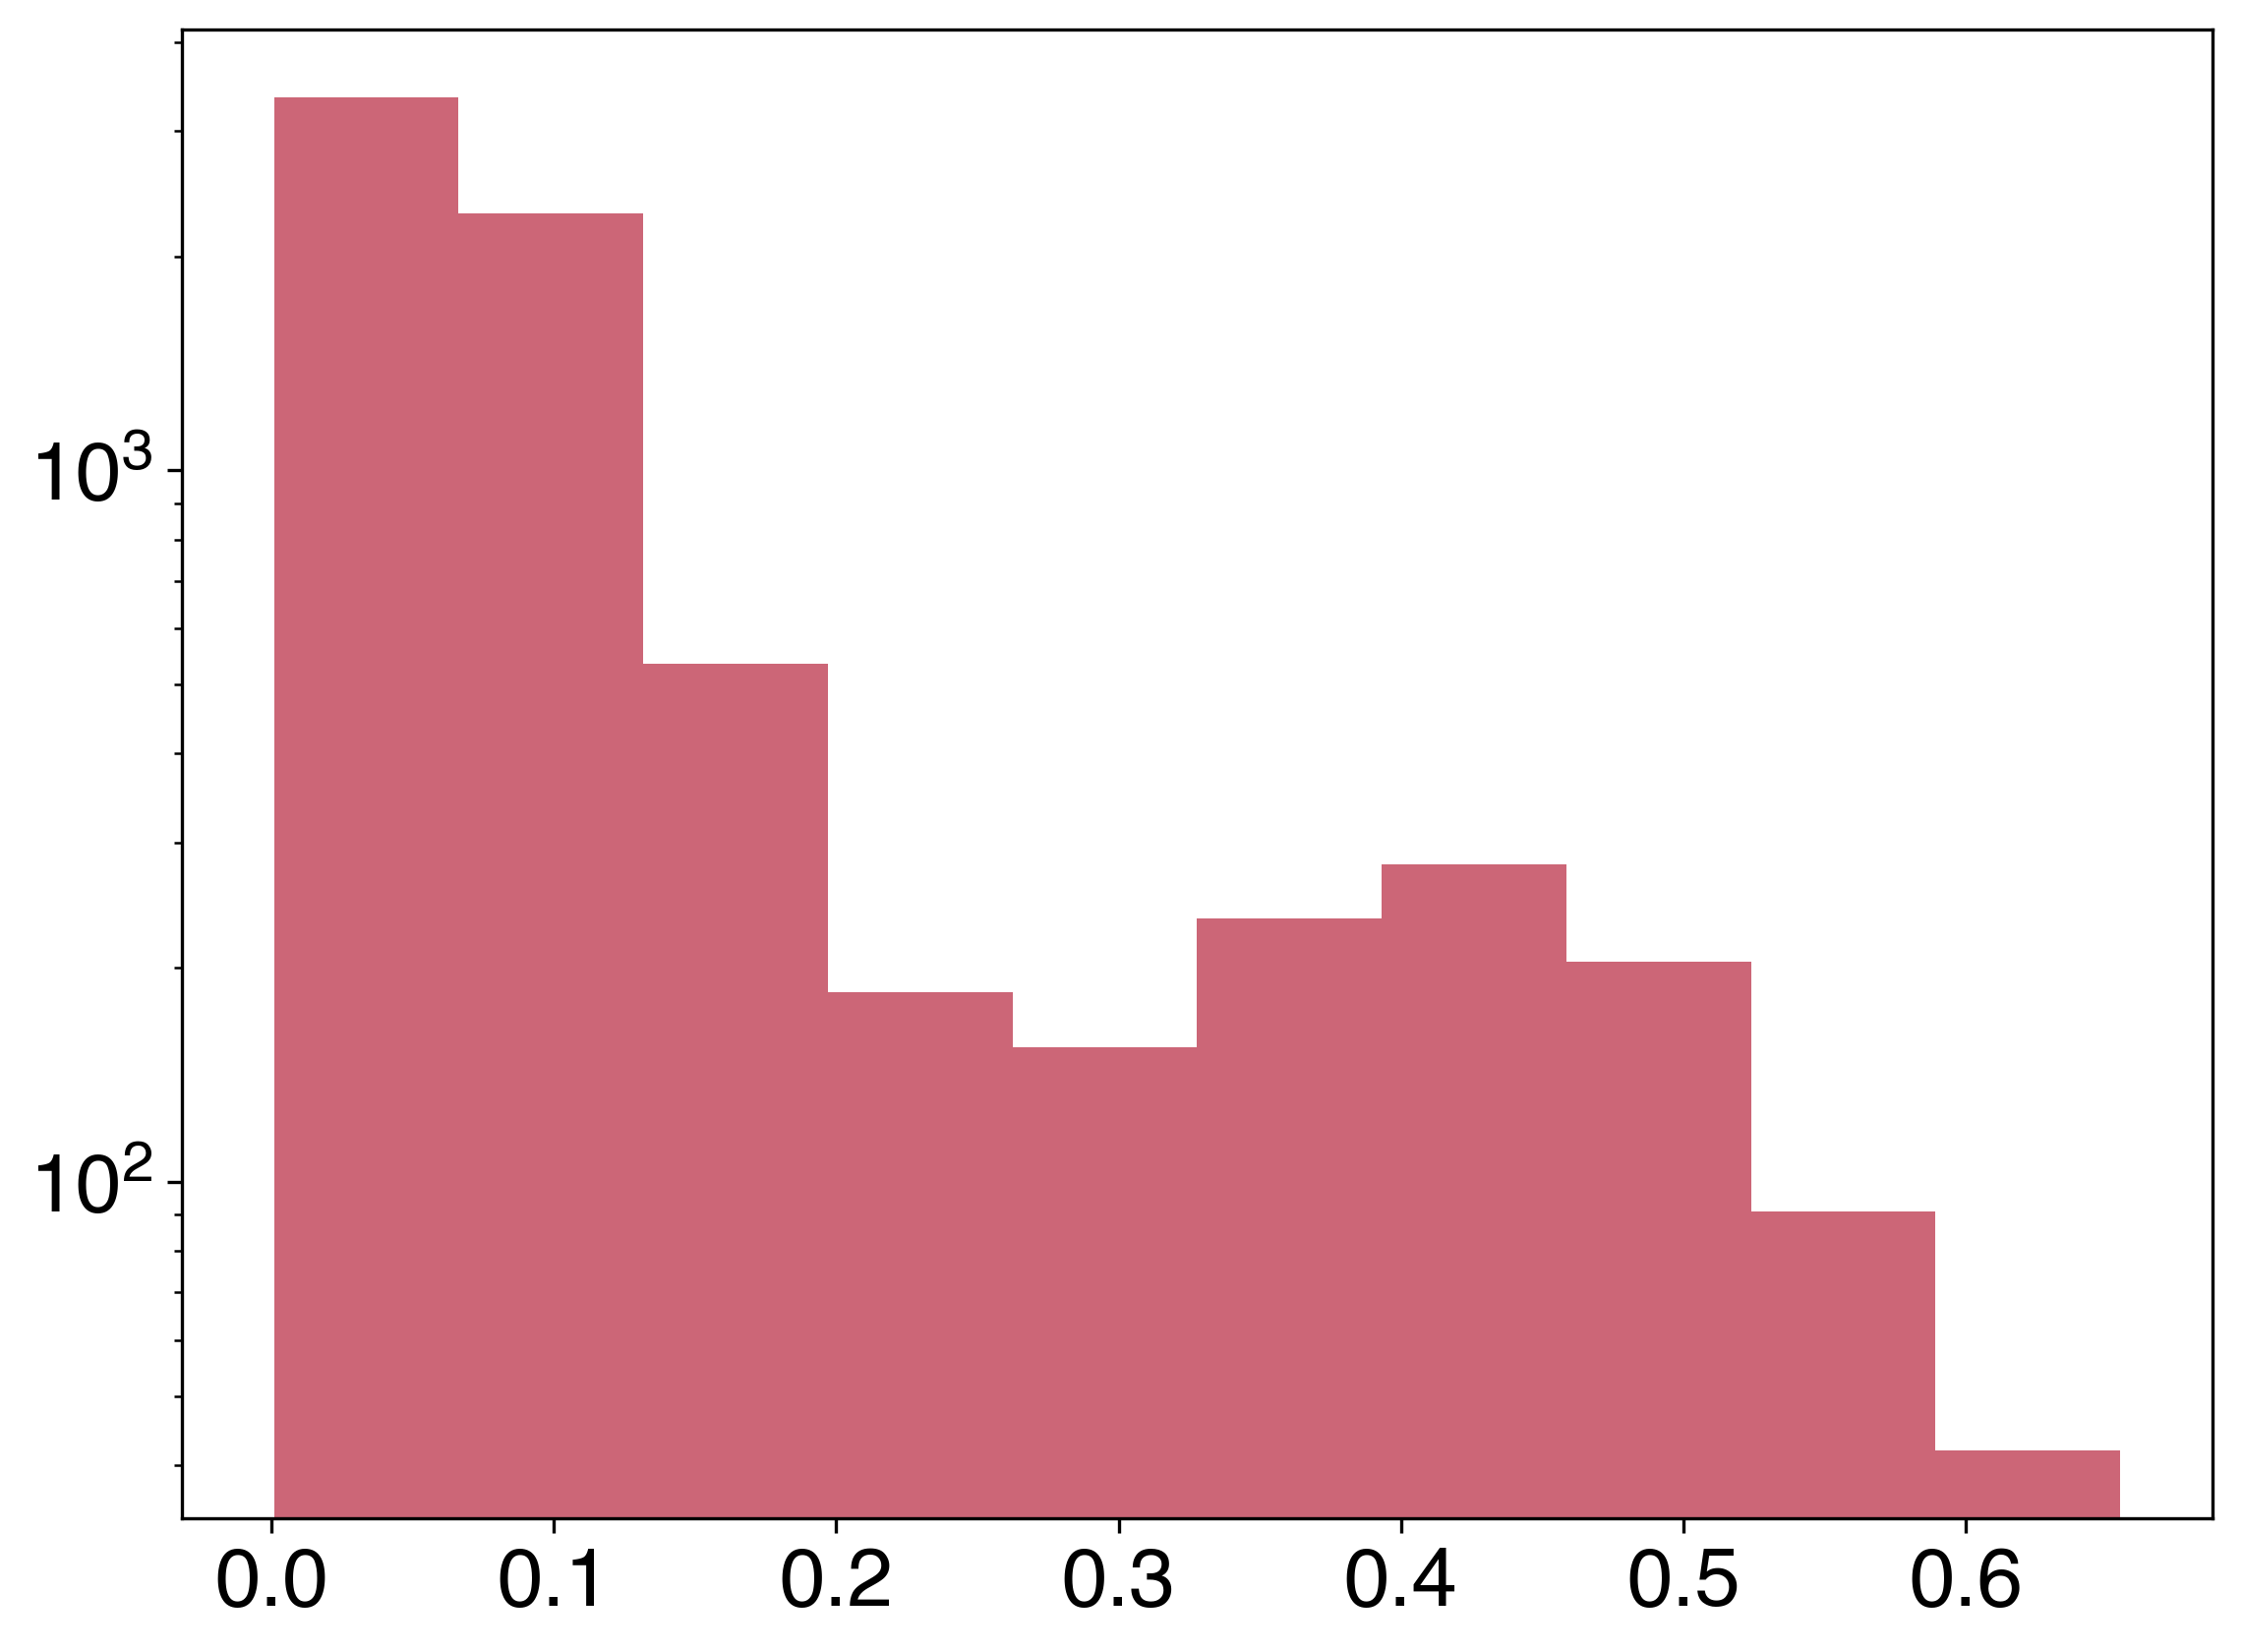

In [5]:
fig, ax = plt.subplots()

ax.hist(track['v'])

ax.set(yscale='log')